#### **1. Wprowadzenie i cel projektu**
Dane zawierają informacje o 150 kwiatach irysa. Każdy z nich opisany jest 4 cechami:
- Długość działki kielicha (sepal length)
- Szerokość działki kielicha (sepal width)
- Długość płatka (petal length)
- Szerokość płatka (petal width)

**Cel:** Na podstawie tych wymiarów musimy przypisać kwiatek do jednego z trzech gatunków: *Iris-setosa*, *Iris-versicolor* lub *Iris-virginica*.

#### **2. Przygotowanie danych**
Import bibliotek oraz pobranie bazy danych.

In [1]:
import os
import kagglehub
import pandas as pd

path = kagglehub.dataset_download('uciml/iris')
print('Ścieżka do plików: ', path)

files = os.listdir(path)
print(files)

c:\Users\patry\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ścieżka do plików:  C:\Users\patry\.cache\kagglehub\datasets\uciml\iris\versions\2
['database.sqlite', 'Iris.csv']


In [2]:
csv_path = os.path.join(path, files[1])

data = pd.read_csv(csv_path)
print(data.shape)
data.info()

(150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [3]:
data = data.set_index('Id')
data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


Z powyższych informacji wynika, że analizowana baza danych składa się z 6 kolumn i 150 wierszy.  
Wszystkie wiersze są uzupełnione i nie brakuje żadnych danych.

#### **3. Eksploracyjna analiza danych (EDA)**


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print(data.describe())

# Sprawdzenie czy klasy są zrównoważone (powinno być po 50 na każdy gatunek)
print(data['Species'].value_counts())

       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.300000       5.100000      1.800000
max         7.900000      4.400000       6.900000      2.500000
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


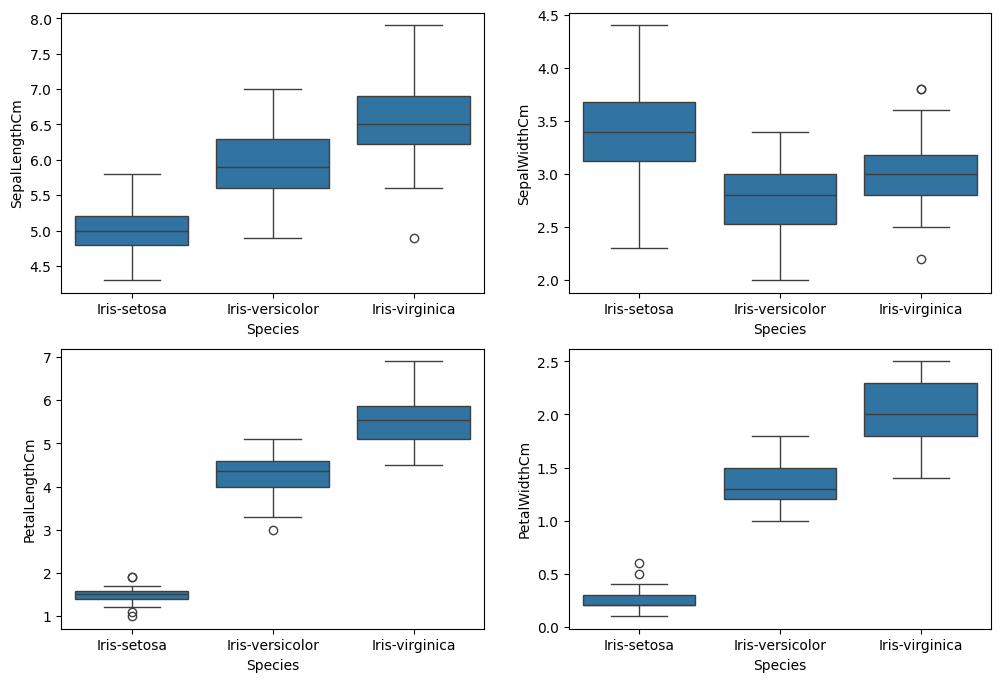

In [5]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.boxplot(x='Species', y='SepalLengthCm', data=data)
plt.subplot(2, 2, 2)
sns.boxplot(x='Species', y='SepalWidthCm', data=data)
plt.subplot(2, 2, 3)
sns.boxplot(x='Species', y='PetalLengthCm', data=data)
plt.subplot(2, 2, 4)
sns.boxplot(x='Species', y='PetalWidthCm', data=data)
plt.show()

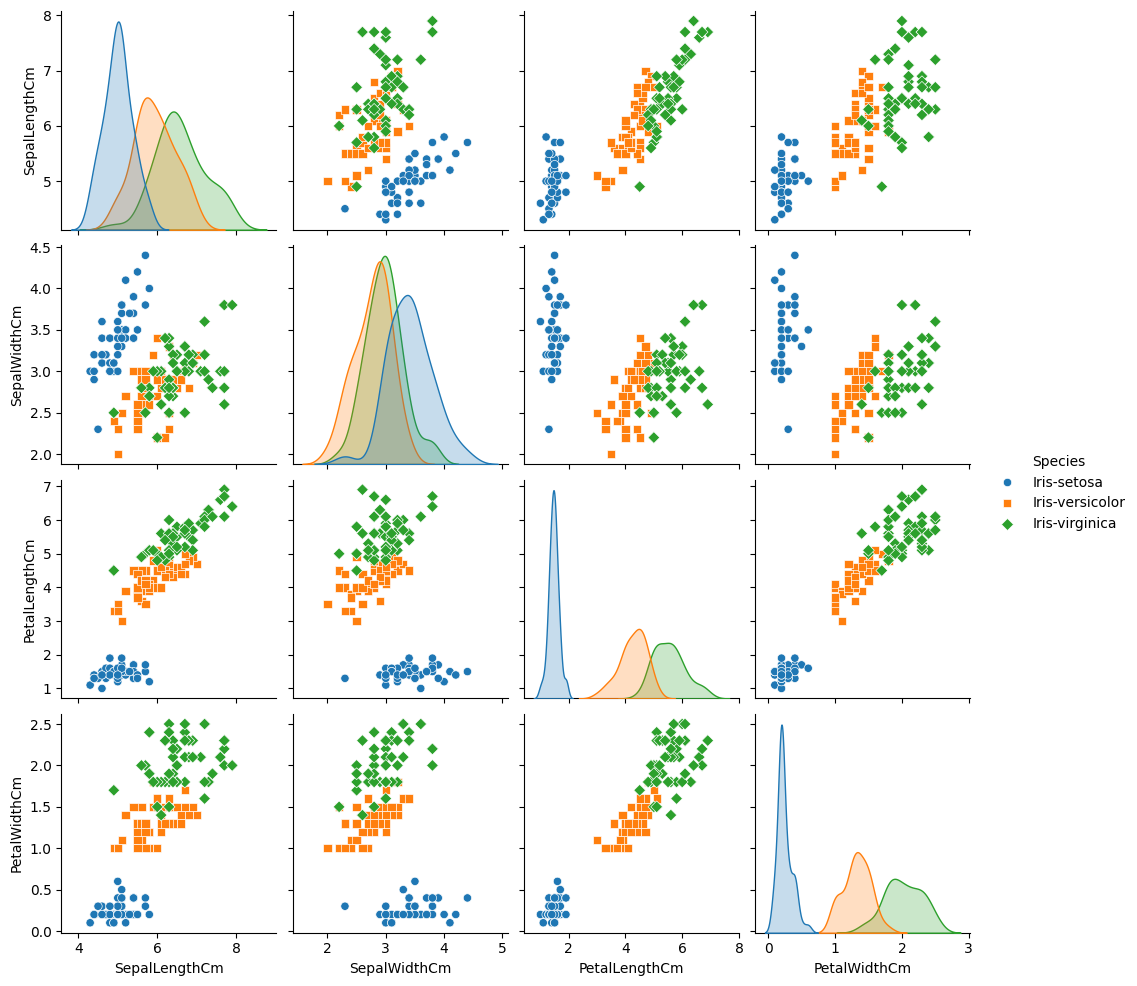

In [6]:
sns.pairplot(data, hue='Species', markers=["o", "s", "D"])
plt.show()

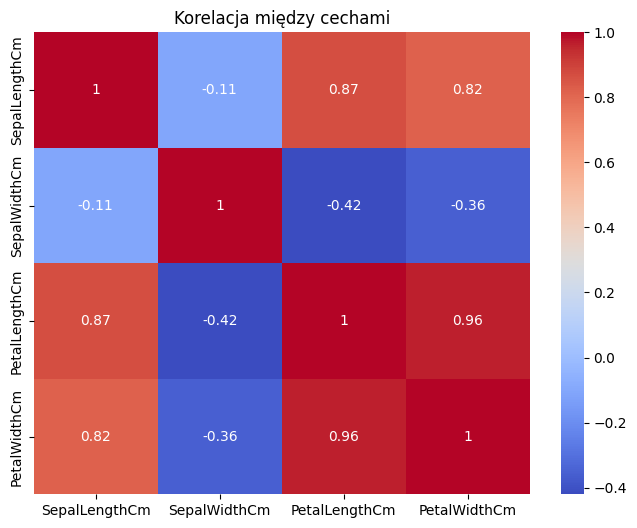

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.drop('Species', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Korelacja między cechami")
plt.show()

Na podstawie powyższych wykresów można łatwo zauważyć, że *Iris-setosa* jest gatunkiem wyraźnie odstającym od dwóch pozostałych, więc model nie powinien mieć problemu z jego klasyfikacją. Cechy które szczególnie go wyróżniają to *PetalLengthCm* oraz *PetalWidthCm*. Są to również cechy między którymi zachodzi największa korelacja.

#### **4. Przygotowanie danych (Preprocessing)**

In [8]:
data

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
146,6.7,3.0,5.2,2.3,Iris-virginica
147,6.3,2.5,5.0,1.9,Iris-virginica
148,6.5,3.0,5.2,2.0,Iris-virginica


Wydzielę teraz cechy potrzebne do wyuczenia modelu (*X*) oraz kolumnę z nazwami gatunków (*y*).  
Podzielę również dane na testowe i treningowe.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = data.drop(['Species'], axis=1)
y = data['Species']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Rozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru testowego: {X_test.shape}")

Rozmiar zbioru treningowego: (120, 4)
Rozmiar zbioru testowego: (30, 4)


#### **5. Wybór i trenowanie modelu**

In [10]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)
print('Model został wytrenowany!')

Model został wytrenowany!


Do wytrenowania mojego modelu wybrałem algorytm *Decision Tree*, ponieważ przy tak małym i prostym zbiorze danych powinien on sobie bardzo dobrze poradzić, a dodatkowo będę mógł zwizualizować proces myślowy komputera.

#### **6. Ewaluacja**

In [11]:
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix, classification_report

predict = model.predict(X_test)

score = mean_absolute_error(y_test, predict)
print('MAE: ', score)

accuracy = accuracy_score(y_test, predict)
print(f"Dokładność modelu: {accuracy * 100:.2f}%")

print('\nRaport klasyfikacji:')
print(classification_report(y_test, predict, target_names=le.classes_))

MAE:  0.0
Dokładność modelu: 100.00%

Raport klasyfikacji:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



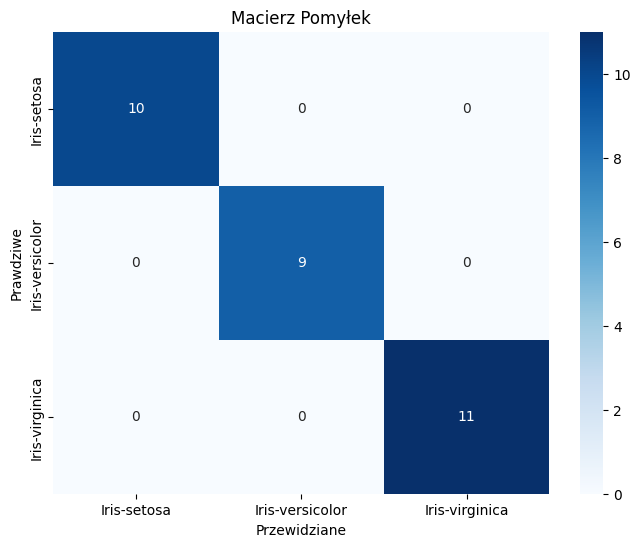

In [12]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Przewidziane')
plt.ylabel('Prawdziwe')
plt.title('Macierz Pomyłek')
plt.show()

Jak można zauważyć, dokładność modelu wyniosła 100%.  
Choć teoretycznie jest to idealny wynik, to w rzeczywistości powinien on nas zaniepokoić i powinniśmy się zastanowić, czy przypadkiem nie doszło do *overfittingu*, ponieważ w prawdziwych warunkach taki wynik jest rzadkością. Jednak w tym przypadku ze względu na tak prosty zbiór danych uzyskany wynik jest prawidłowy.

#### BONUS

Poniżej można przeanalizować proces decyzyjny mojego modelu.

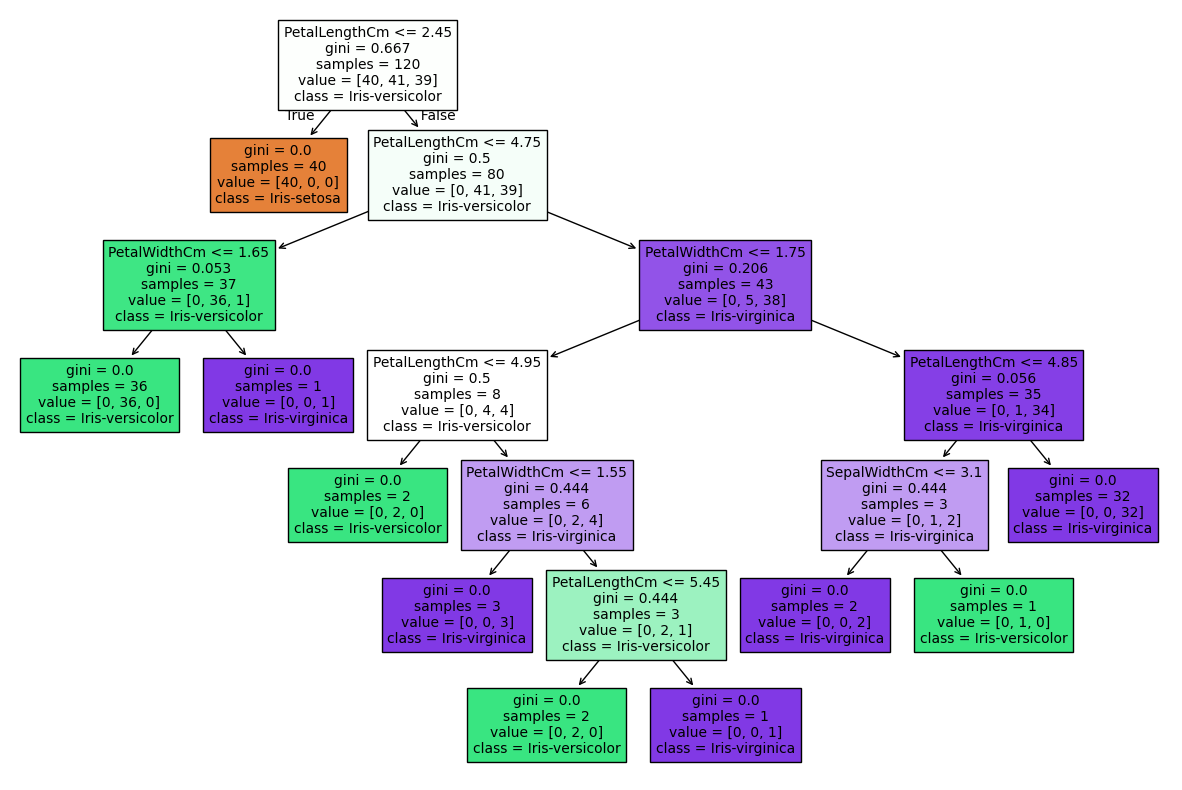

In [13]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(model, feature_names=X.columns, class_names=le.classes_, filled=True)
plt.show()